In [1]:
import pandas as pd
import easygui
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from numpy.random import random
from plotly.subplots import make_subplots
import os

In [2]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [3]:
data_load = []
def way_to_data():
    root_dir = 'C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data (csv)\\Parameters\\'
    all_files = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            full_path = os.path.join(dirpath, filename)
            if 'csv' in full_path:
                data_load.append(full_path)

In [4]:
way_to_data()

In [5]:
data = pd.DataFrame()
data['payload'] = pd.read_csv('Payload.csv')['max'].values[:3987]
data['north'] = pd.read_csv('North.csv')['max'].values[:3987]
data['south'] = pd.read_csv('South.csv')['max'].values[:3987]
data['TWT'] = pd.read_csv('TWT Current2.csv')['max'].values[:3987]
data['liquid'] = list(np.ones(2903)) + list(np.ones(1084)/2)
data['CoolingLoss'] = [0 if x==1 else 0.5 if x==0.5 else 1 for x in data['liquid']]
data['currentSquare'] = data['TWT']**2
data['payloadXcurrent'] = data['payload']/100 * data['TWT']

In [ ]:
for name in data_load: 
    data['temperature'] = pd.read_csv(name)['max'].values[:3987]

    numeric_features = ['payload', 'north', 'south', 'TWT', 'currentSquare', 'payloadXcurrent', 'CoolingLoss']
    ohe_features = ['liquid']
    X = data[numeric_features + ohe_features]
    y = data['temperature']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    scaler = MinMaxScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
    X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])
    
    mlp_model = MLPRegressor(
        hidden_layer_sizes=(200, 100, 50, 25), 
        activation='relu', 
        solver='adam', 
        alpha=0.0001,                        
        max_iter=1500,                        
        learning_rate_init=0.0005,            
        random_state=42,
        verbose=True                          
    )
    mlp_model.fit(X_train_scaled, y_train)
    joblib.dump(mlp_model, f'TrainedData\\MLP2\\model{name.split('\\')[-1].split('.')[0]}.pkl')
    joblib.dump(scaler, f'TrainedData\\MLP2\\scaler{name.split('\\')[-1].split('.')[0]}.pkl')

## Cheking models

In [3]:
models_load = easygui.fileopenbox(filetypes="*.txt",multiple=True)
scalers_load = easygui.fileopenbox(filetypes="*.txt",multiple=True)

In [4]:
data_predict = pd.DataFrame(columns = ['payload', 'north', 'south', 'TWT', 'currentSquare', 'payloadXcurrent', 'CoolingLoss', 'liquid'])
data_predict['payload'] = pd.read_csv('Payload.csv')['max'].values
data_predict['north'] = pd.read_csv('North.csv')['max'].values
data_predict['south'] = pd.read_csv('South.csv')['max'].values
data_predict['TWT'] = pd.read_csv('TWT Current.csv')['max'].values
data_predict['currentSquare'] = data_predict['TWT']**2
data_predict['payloadXcurrent'] = data_predict['payload']/100 * data_predict['TWT']

In [5]:
Ev1 = list(list(np.ones(2903)) + list(np.ones(901+1429)/2)) # ЖК1 не отказал
Ev2 = list(list(np.ones(2903)) + list(np.ones(901+214)/2) + list(np.zeros(1429-214))) # ЖК1 отказал 01.01.2026
Ev3 = list(list(np.ones(2903)) + list(np.ones(901+365+214)/2) + list(np.zeros(1429-365-214))) # ЖК1 отказал 01.01.2027

In [10]:
dictionary_final = defaultdict(list)

In [25]:
count = 0
for x in range(3):
    if x == 0:
        EVA = Ev1
        name_Sheet = 'ЖК1 не отказал'
    if x == 1:
        EVA = Ev2
        name_Sheet = 'ЖК1 отказал 01.01.2026'
    if x == 2:
        EVA = Ev3
        name_Sheet = 'ЖК1 отказал 01.01.2027'
    data_predict['CoolingLoss'] = [0 if x==1 else 0.5 if x==0.5 else 1 for x in EVA]
    data_predict['liquid'] = EVA
    dictionary_final = defaultdict(list)
    data_limits = pd.read_excel('limits.xlsx', sheet_name = 'data')
    dates = pd.date_range(start = '2015-01-01', end = '2029-04-29', freq = 'D')
    for x,y in zip(models_load, scalers_load):
        name = x.split('model')[1].split('.pkl')[0]
        loaded_mlp_model = joblib.load(f'{x}')
        loaded_scaler = joblib.load(f'{y}')
        X_new_predict = pd.DataFrame(data_predict)
        numeric_features = ['payload', 'north', 'south', 'TWT', 'currentSquare', 'payloadXcurrent', 'CoolingLoss']
        X_new_scaled = X_new_predict.copy()
        X_new_scaled[numeric_features] = loaded_scaler.transform(X_new_predict[numeric_features])
        y_pred_extrapolated = loaded_mlp_model.predict(X_new_scaled)
        max = data_limits['Limit'].iloc[list(data_limits['Parameters']).index(name)]
        maximum = y_pred_extrapolated.max()
        if len(y_pred_extrapolated[y_pred_extrapolated > max]) > 0:
            out_value = y_pred_extrapolated[y_pred_extrapolated > max][0]
            out_date = str(dates[list(y_pred_extrapolated).index(out_value)]).split(' ')[0]
            max_value = pd.read_csv(data_load[[name in x for x in data_load].index(True)])['max'].max()
            dictionary_final[name].append([name, out_date, out_value, out_value - max_value, maximum])
        outDataFrame = pd.DataFrame(columns = ['Параметр', 'Дата', 'Температура на Дату', 'Запас', 'Максимальная прогнозируемая температура'])
        for x, y in zip(list(dictionary_final.keys()), range(len(list(dictionary_final.keys())))):
            outDataFrame.loc[y] = dictionary_final[x][0]
        outDataFrame['Температура на Дату'] = [round(x,2) for x in outDataFrame['Температура на Дату']]
        outDataFrame['Запас'] = [round(x,2) for x in outDataFrame['Запас']]
        outDataFrame['Максимальная прогнозируемая температура'] = [round(x,2) for x in outDataFrame['Максимальная прогнозируемая температура']]
    path = 'C:\\Users\\sadykpayev\\Desktop\\Джуниор\\\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\Результаты1.xlsx'
    with pd.ExcelWriter(path, engine='openpyxl' , mode='a') as writer:
        outDataFrame.to_excel(writer, sheet_name=name_Sheet, index=False)

### Saving to csv

In [ ]:
count = 0
for x in range(3):
    if x == 0:
        EVA = Ev1
        way = 'prediction\\csv. Без Отказа\\'
#    if x == 1:
#        EVA = Ev2
#        name_Sheet = 'ЖК1 отказал 01.01.2026'
    if x == 2:
        EVA = Ev3
        way = 'prediction\\csv. Отказ 01.01.2027\\'
    data_predict['CoolingLoss'] = [0 if x==1 else 0.5 if x==0.5 else 1 for x in EVA]
    data_predict['liquid'] = EVA
    dictionary_final = defaultdict(list)
    data_limits = pd.read_excel('limits.xlsx', sheet_name = 'data')
    dates = pd.date_range(start = '2015-01-01', end = '2029-04-29', freq = 'D')
    for x,y in zip(models_load, scalers_load):
        name = x.split('model')[1].split('.pkl')[0]
        loaded_mlp_model = joblib.load(f'{x}')
        loaded_scaler = joblib.load(f'{y}')
        X_new_predict = pd.DataFrame(data_predict)
        numeric_features = ['payload', 'north', 'south', 'TWT', 'currentSquare', 'payloadXcurrent', 'CoolingLoss']
        X_new_scaled = X_new_predict.copy()
        X_new_scaled[numeric_features] = loaded_scaler.transform(X_new_predict[numeric_features])
        y_pred_extrapolated = loaded_mlp_model.predict(X_new_scaled)
        prediction_csv = pd.DataFrame()
        prediction_csv['date'] = dates
        prediction_csv['max'] = [round(x,2) for x in y_pred_extrapolated]
        prediction_csv.to_csv(f'{way}{x.split('model')[1].split('.pkl')[0]}.csv', index = False)

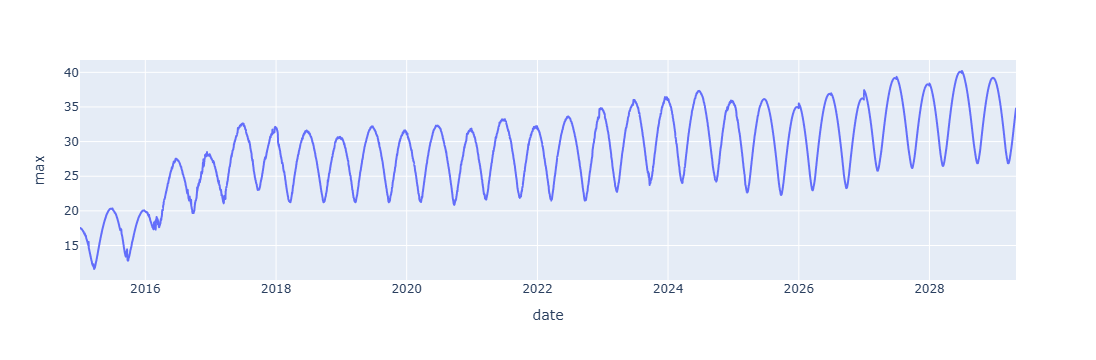

In [21]:
px.line(data_frame = pd.read_csv('prediction\\csv. Отказ 01.01.2027\\Т2Ж.csv'), x = 'date', y = 'max')

In [ ]:
fig = go.Figure()
fig.add_trace(go.Line(x = pd.read_csv(data_load[94])['Дата'], y = pd.read_csv(data_load[94])['max']))
fig.add_trace(go.Line(x = pd.date_range(start = '2015-01-01', end = '2029-04-29', freq = 'D'), y = y_pred_extrapolated))